# Figure 6 and Supplementary Figure 8

>
> Before running this notebook, please make sure to install the required packages:
>
> From pip:
> - pandas
> - logomaker
> 
> From github:
> - py-mfdca (https://github.com/utdal/py-mfdca)
> 
> Install the previous repository via pip to include other requirements as biopython and numpy:
> Additionally, you need will need hmmer to align the WT sequences to the Pfam domain:
> - hmmer (https://hmmer.org/)
>

## Preparing the data
### Load the required libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
import logomaker as lm
from dca import helper_functions
from dca.dca_class import dca
import subprocess
import warnings
from scipy.stats import spearmanr, pearsonr

warnings.filterwarnings("ignore", category=FutureWarning, module="logomaker")

MSADir=Path("MSAs")
UTSWDir = Path("data")
CleanFigDir = Path("figures")
PfamMSA = MSADir / "PF13354_ga.fasta"

### Loading raw data
We open and organize the data into a data frame and compute the median for $Fitness_{local}$. Remove non-intended barcodes and sequences.

In [4]:
parquetAmp = pd.read_parquet(UTSWDir.joinpath('amp_auc_wide_df.parquet'))
parquetAzt = pd.read_parquet(UTSWDir.joinpath('azt_auc_wide_df.parquet'))

# Extract concentration from column names and compute the median for each concentration group
def compute_median(data, prefix):
    concentration_columns = {}
    for col in data.columns:
        if not col.startswith(prefix):
            continue
        parts = col.split()
        concentration = parts[1]
        if concentration not in concentration_columns:
            concentration_columns[concentration] = []
        concentration_columns[concentration].append(col)
    
    averaged_columns = {concentration: data[cols].median(axis=1, skipna=True) for concentration, cols in concentration_columns.items()}
    return averaged_columns

def count_letters(profile):
    return sum(1 for char in profile if char.isalpha())

# Compute median for Ampicillin
averaged_columns_amp = compute_median(parquetAmp, "Ampicillin")
Average_AMP = pd.DataFrame({
    "Code": parquetAmp[""],
    "Profile": parquetAmp["mut_profile_masked"],
    "N. Mut.": parquetAmp["mut_profile_masked"].apply(count_letters),
    **averaged_columns_amp
})

# Compute median for Aztreonam
averaged_columns_azt = compute_median(parquetAzt, "Aztreonam")
Average_AZT = pd.DataFrame({
    "Code": parquetAzt[""],
    "Profile": parquetAzt["mut_profile_masked"],
    "N. Mut." : parquetAzt["mut_profile_masked"].apply(count_letters),
    **averaged_columns_azt
})

# Save the results to CSV files
Average_AMP.to_csv(UTSWDir.joinpath('Average_AMP.csv'), index=False)
Average_AZT.to_csv(UTSWDir.joinpath('Average_AZT.csv'), index=False)

WT_seq = 'LQMERMAGERTRN'
def replace_characters(profile, base):
    return ''.join(base[i] if profile[i] == '.' else profile[i] for i in range(len(base)))

Average_AMP['Reduced_Seq'] = Average_AMP['Profile'].apply(lambda x: replace_characters(x, WT_seq))
Average_AZT['Reduced_Seq'] = Average_AZT['Profile'].apply(lambda x: replace_characters(x, WT_seq))

WT_AMP=Average_AMP[Average_AMP["N. Mut."]==0]
WT_AZT=Average_AZT[Average_AZT["N. Mut."]==0]
concentration_amp = Average_AMP.columns[3:9].values.tolist()
concentration_azt = Average_AZT.columns[3:11].values.tolist()
intended_codes = pd.read_csv(UTSWDir.joinpath('TEM1-combinatorial-mutagenesis-intended.csv'))

Average_AMP_selected_cleaned = Average_AMP[Average_AMP['Profile'].isin(intended_codes['mut_profile_masked'])].copy()
Average_AZT_selected_cleaned = Average_AZT[Average_AZT['Profile'].isin(intended_codes['mut_profile_masked'])].copy()

print("Cleaned selected AMP dataset: ", len(Average_AMP_selected_cleaned))
print("Cleaned selected AZT dataset: ", len(Average_AZT_selected_cleaned))

Cleaned selected AMP dataset:  55293
Cleaned selected AZT dataset:  55293


## Learning from the Pfam domain
### Filter MSA
We filter at 5\% gaps of our MSA:

In [5]:
MSAGapPct = 5
MSALen = len(next(SeqIO.parse( PfamMSA,'fasta')))
maxGaps = round( MSAGapPct * MSALen / 100 )

print(f'MSA length: {MSALen}, max gaps: {maxGaps}')

PfamMSA_filt = PfamMSA.with_name(PfamMSA.stem + '_filtered_5pct.fasta')
#save filtered_ MSA for use later in the notebook.
helper_functions.filter_pfam( str(PfamMSA), maxGaps, str(PfamMSA_filt))

MSA length: 214, max gaps: 11
Original number of sequences: 104744

Number(%) of sequences excluded: 77503 (73.99%)



### Align to MSA
Align the wiltype sequences of TEM1 to the MSA of the Pfam domain using the hmm algorithm.

> **This step requires you to have hmmer availible in your system**

Note: If you run this cell a second time, an error will be raised. You can ignore it or delete the .h3i file that was created in the MSA directory

In [7]:
# Align the filtered MSA and structure
hmmFile = MSADir / 'PF13354.hmm'
scanFile = MSADir / 'TEM1_263AA.scan'
pdbFasta = MSADir / 'TEM1_263AA.fasta'
# Use hmmpress to prepare hmmprofile for use
hmmpress_command = ['hmmpress', str(hmmFile)]
# Command to align your sequence to the alignment
hmmscan_command = ['hmmscan', '-o', str(scanFile),'--notextw', str(hmmFile), str(pdbFasta)]
                         
subprocess.run(hmmpress_command)
subprocess.run(hmmscan_command)

# parse the scan file to build an align file, to be used later. 
alignFile = MSADir / 'TEM1_263AA.align'
important_scan_lines = []
counter = 0
record = False
with open( scanFile ,'r') as fd:
    all_lines = fd.readlines()
    for line in all_lines:
        if 'domain' in line and 'score' in line and 'E-value' in line: # start recording lines
            record = True
        elif record == True and counter < 4:
            line_to_check = line.split()
            try:
                int(line_to_check[1])
                important_scan_lines.append(line.rstrip())
                counter+=1
            except:
                counter+=1
                
# build align file
with open( alignFile, 'w') as output:
    for alignment in important_scan_lines[:2]: # first two important_scan_lines are what we need
        to_print = alignment.split()
        for line in to_print:
            output.writelines(line+'\n')
        output.writelines('\n')

# build alignment dictionary
alignment_dictionary = helper_functions.backmap_alignment(str(alignFile))
aligDict_pdb2Fasta = {v: k for k, v in alignment_dictionary.items()}

Working...    done.
Pressed and indexed 1 HMMs (1 names and 1 accessions).
Models pressed into binary file:   MSAs/PF13354.hmm.h3m
SSI index for binary model file:   MSAs/PF13354.hmm.h3i
Profiles (MSV part) pressed into:  MSAs/PF13354.hmm.h3f
Profiles (remainder) pressed into: MSAs/PF13354.hmm.h3p


### Figure 6A
β-lactamase family (PF13354) sequence logo for each site position in the mutational library. TEM-1 wildtype amino acids listed on x-axis. 

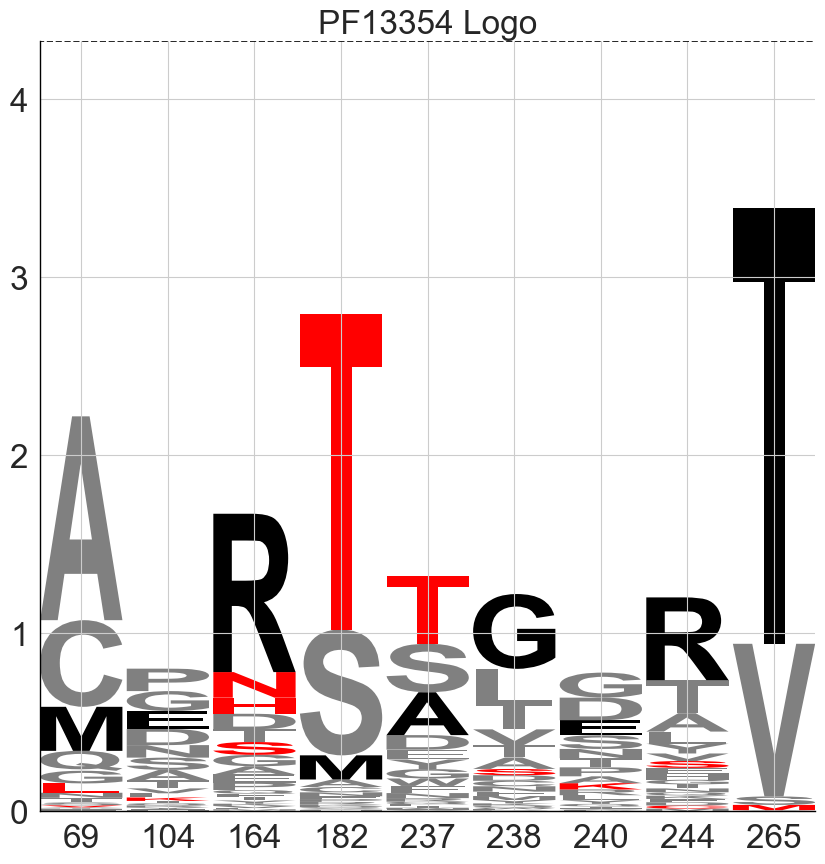

In [13]:
FamilySeq = []

mutatedPositions = np.array([44,79,139,157,212,213,214,218,238])
for i in range(len(mutatedPositions)):
    mutatedPositions[i] = aligDict_pdb2Fasta[mutatedPositions[i]]

with open(PfamMSA_filt) as fastafile:
    for idx, record in enumerate(SeqIO.parse(fastafile, "fasta")):
        seq = str(record.seq)
        redseq = ''.join(seq[i-1] for i in mutatedPositions)
        FamilySeq.append(redseq)
counts_mat3 = lm.alignment_to_matrix(FamilySeq,to_type='information',pseudocount=0.01)

# make Figure and Axes objects
fig, ax = plt.subplots(1,1,figsize=(10,10))
logo= lm.Logo(counts_mat3,ax=ax)

WTref= 'MERMAGERT'
# Set up your colors
black = 'black'
grey = '#808080'

intended_mut = {0: ['L','V'], 1: ['K'], 2: ['S','H','N'],
            3: ['T'], 4: ['T'], 5: ['S'],
            6: ['K'], 7: ['S','C'], 8: ['M']}

MutDict = {i:[] for i in range(len(WTref))}
for i in range(len(WTref)):
    sort_row= counts_mat3.loc[i].sort_values()
    for j in range(len(intended_mut[i])):
        rank = sort_row.index.get_loc(intended_mut[i][j])
        MutDict[i].append(rank)

PosDict = {}
for i in range(len(WTref)):
    sort_row = counts_mat3.loc[i].sort_values()
    rank = sort_row.index.get_loc(WTref[i])
    PosDict[i] = rank

for idx_p,patch in enumerate(logo.ax.patches):
    # Each patch corresponds to a letter at a position
    pos = idx_p//21  # X location is the position
    ranking = idx_p % 21
    if ranking == PosDict[pos]:
        patch.set_facecolor(black)
    else:
        patch.set_facecolor(grey)

    for mutant in MutDict[pos]:
        if ranking == mutant:
            patch.set_facecolor('#FF0000')

logo.style_spines(visible=False)
logo.style_spines(spines=['left', 'bottom'], visible=True)
logo.style_xticks(rotation=0, fmt='%d', anchor=0)
ax.set_title('PF13354 Logo')
labelPositions = ['69', '104', '164', '182', '237', '238', '240', '244', '265']
logo.ax.set_xticklabels(labelPositions,fontsize=24)
logo.ax.set_yticks(np.arange(0, 5, 1))
logo.ax.set_yticklabels(np.arange(0, 5, 1), fontsize=24)
ax.set_ylim(0,np.log2(20))
ax.hlines(np.log2(20),-0.5,9, color='black', ls='dashed')
plt.savefig(CleanFigDir.joinpath('FamilyLogo_6a.png'), dpi=600, bbox_inches='tight', transparent=True)
plt.savefig(CleanFigDir.joinpath('FamilyLogo_6a.pdf'), dpi=600, bbox_inches='tight', transparent=True)

### DCA Analysis
We use the DCA analysis to identify the co-evolving residues in the protein and evaluate hamiltonian and effective alphabet:

In [9]:
familyModel = dca(str(PfamMSA_filt))
familyModel.mean_field()
print('Summary of MSA and Effective # of Sequences:')
print("M = "+str(familyModel.M)+' , N = '+str(familyModel.N))
print("Meff = "+ str(familyModel.Meff))

Summary of MSA and Effective # of Sequences:
M = 27242 , N = 214
Meff = 8514.693301255807


### Compute Hamiltonian and Effective alphabet
We compute the Hamiltonian for the whole PF13354 family. We also look for the WT entry in the MSA and compute its effective alphabet.

In [10]:
OutputH_fam = familyModel.compute_Hamiltonian(str(PfamMSA_filt))

headers = OutputH_fam[1]
H_fam = OutputH_fam[0]

for idx, name in enumerate(headers):
    if 'P62593' in name:
        P62593_idx = idx
        TEM1_ham_fam = H_fam[idx]
        TEM1_name_fam = name
        print(f'TEM1 name: {TEM1_name_fam}')

with open(PfamMSA_filt) as fastafile:
    for idx, record in enumerate(SeqIO.parse(fastafile, "fasta")):
        if  TEM1_name_fam in record.description:
            TEM1_record = record

# Create a list with the single record
TEM1_MSA_file = MSADir / "TEM1_single_MSA.fasta"
SeqIO.write([TEM1_record], TEM1_MSA_file, "fasta")
print(f"Single-entry MSA written to {TEM1_MSA_file}")

TEM1_EffAlph_fam = familyModel.compute_EffAlphabet(str(TEM1_MSA_file))[0]
OutputEffAlph_fam = familyModel.compute_EffAlphabet(str(PfamMSA_filt))

TEM1 name: sp|P62593|BLAT_ECOLX/48-261
Single-entry MSA written to MSAs/TEM1_single_MSA.fasta


### Figure 6B
Effective alphabet for each position based on the context mutability of the TEM-1 E. coli sequence as compared to the mutability of those sites for the whole family.

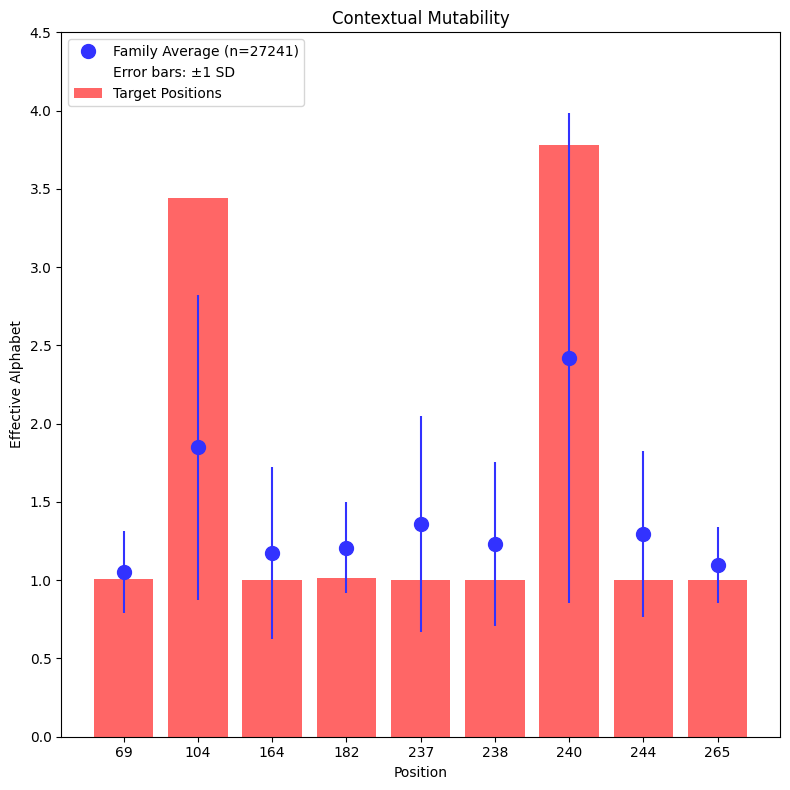

In [11]:
labelPositions = ['69', '104', '164', '182', '237', '238', '240', '244', '265']
palette = sns.color_palette("bwr", n_colors=9)
plt.figure(figsize=(8,8))
ax = plt.gca()

plt.errorbar(x=range(0,len(mutatedPositions)), y=OutputEffAlph_fam[:,mutatedPositions-1].mean(axis=0),
             yerr=OutputEffAlph_fam[:,mutatedPositions-1].std(axis=0), fmt='o', label='Family Average (n=27241)', color=palette[0], ms=10)

plt.bar(labelPositions,TEM1_EffAlph_fam[mutatedPositions-1],label='Target Positions',color=palette[-2])
# plt.xticks(np.arange(0,familyModel.N,10));plt.xlim(0,familyModel.N+1);plt.ylim(0.9,6.5)
plt.plot([], [], ' ', label='Error bars: ±1 SD')
plt.legend(loc='upper left')
handles, labels = ax.get_legend_handles_labels()
order = [labels.index('Family Average (n=27241)'),
         labels.index('Error bars: ±1 SD'),
         labels.index('Target Positions')]
ax.legend([handles[i] for i in order], [labels[i] for i in order], loc='upper left')
# plt.grid(color='gray')
plt.title('Contextual Mutability')
plt.xlabel('Position')
plt.ylabel('Effective Alphabet')
plt.ylim(0,4.5)
plt.tight_layout()
plt.savefig(CleanFigDir / 'TEM1_EffAlph_fam_ga_SpecificPositions_6b.png', dpi=600)
plt.savefig(CleanFigDir / 'TEM1_EffAlph_fam_ga_SpecificPositions_6b.pdf', dpi=600)

## Hamiltonian for CML
We compute the Hamiltonian for the CML. To this end we replace the positions in the WT sequence according to their mutation profil and calculate the Hamiltonian for each of the sequences.

_Note: In the alignment that we generate, we missed some of the mutations that they have tried. We lost the first mutation site at the signal peptide. We also lost the one at position 14 in TEM 1 and the last 2 mutations at 248 and 249._

In [14]:
# Function to replace positions in the base string
def replace_positions(base_string, positions, profile):
    base_list = list(base_string)  # Convert string to list for mutability
    for pos, char in zip(positions, profile[2:]):
        if char != '.':
            base_list[pos - 1] = char  # Replace (convert 1-based to 0-based indexing)
    return ''.join(base_list)  # Convert list back to string

# Apply the function to each row of the DataFrame
Average_AMP_selected_cleaned.loc[:,'Seq_wrtPF13354'] = Average_AMP_selected_cleaned['Profile'].apply(lambda profile: replace_positions(str(TEM1_record.seq), mutatedPositions, profile))
Average_AZT_selected_cleaned.loc[:,'Seq_wrtPF13354'] = Average_AZT_selected_cleaned['Profile'].apply(lambda profile: replace_positions(str(TEM1_record.seq), mutatedPositions, profile))

# Create an MSA with the synthetic sequences
records = []
for _, row in Average_AMP_selected_cleaned.iterrows():
    record = SeqRecord(Seq(row['Seq_wrtPF13354']), id=str(row['Code']), description="")
    records.append(record)
AMP_MSA_wrtPF13354_file = MSADir / 'AMP_MSA_wrtPF13354.fasta'
SeqIO.write(records, AMP_MSA_wrtPF13354_file, "fasta")

records = []
for _, row in Average_AZT_selected_cleaned.iterrows():
    record = SeqRecord(Seq(row['Seq_wrtPF13354']), id=str(row['Code']), description="")
    records.append(record)
AZT_MSA_wrtPF13354_file = MSADir / 'AZT_MSA_wrtPF13354.fasta'
SeqIO.write(records, AZT_MSA_wrtPF13354_file, "fasta")

# Compute the Hamiltonian for the synthetic sequences
HamResults_AMP_MSA_wrtPF13354 = familyModel.compute_Hamiltonian(str(AMP_MSA_wrtPF13354_file))
HamResults_AZT_MSA_wrtPF13354 = familyModel.compute_Hamiltonian(str(AZT_MSA_wrtPF13354_file))
Average_AMP_selected_cleaned.loc[:,'H_fam'] = HamResults_AMP_MSA_wrtPF13354[0]
Average_AZT_selected_cleaned.loc[:,'H_fam'] = HamResults_AZT_MSA_wrtPF13354[0]

### Figure G and H
The relative frequency of variants and the respective Hamiltonian energies for ampicillin (G) and aztreonam (H) experimental fitness scores for the top 2500 variants. 

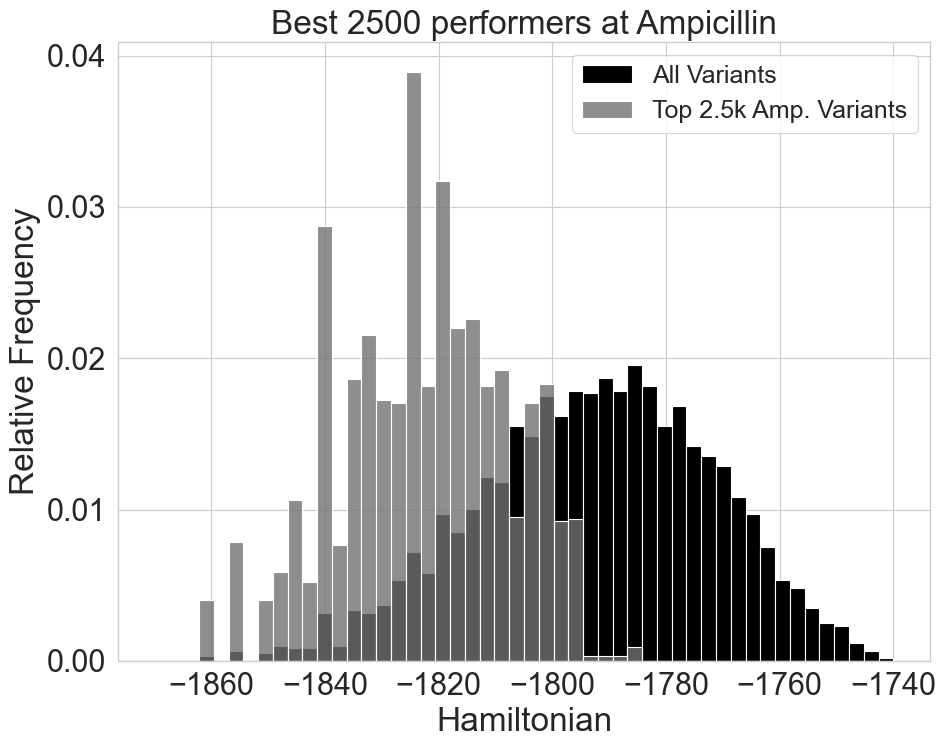

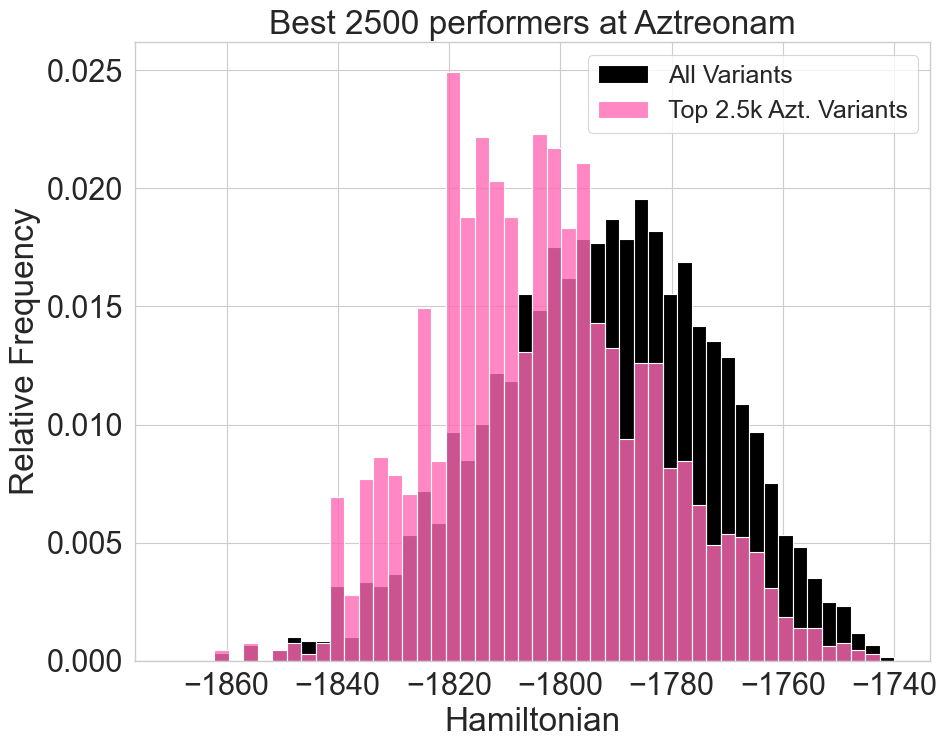

In [15]:
# Filter the DataFrame for the highest 5000 values in the 'H_fam' column
Average_AMP_Glob_top2_5K = Average_AMP_selected_cleaned.nlargest(2500, '781.0')
Average_AZT_Glob_top2_5K = Average_AZT_selected_cleaned.nlargest(2500, '36.0')

palette = sns.color_palette("bwr", n_colors=9)
color_all_data = palette[0]  # First color for all data
color_top_5000 = palette[-1]
bin_edges = np.linspace(-1870, -1740, 51)

# Plot the histograms
sns.set_theme(context='paper',style='whitegrid', font="Arial", font_scale=2.5)  # Adjust font size and style
plt.figure(figsize=(10, 8))
sns.histplot(Average_AMP_selected_cleaned['H_fam'], bins=bin_edges, color='#000000', alpha=1, label='All Variants', stat='density')
sns.histplot(Average_AMP_Glob_top2_5K['H_fam'], bins=bin_edges, color='#727272', alpha=0.8, label='Top 2.5k Amp. Variants', stat='density')
plt.xlabel('Hamiltonian')
plt.ylabel('Relative Frequency')
plt.yticks(np.arange(0, 0.05, 0.01))

plt.title(r'Best 2500 performers at Ampicillin')
plt.legend(fontsize=18)
plt.tight_layout()
plt.savefig(CleanFigDir / 'H_fam_Distribution_withTop2.5k_781AMP_G.png', dpi=600, bbox_inches='tight', transparent=True)
plt.savefig(CleanFigDir / 'H_fam_Distribution_withTop2.5k_781bAMP_G.pdf', dpi=600, bbox_inches='tight', transparent=True)


plt.figure(figsize=(10, 8))
sns.histplot(Average_AZT_selected_cleaned['H_fam'], bins=bin_edges, color="000000", alpha=1, label='All Variants', stat='density')
sns.histplot(Average_AZT_Glob_top2_5K['H_fam'], bins=bin_edges, color='#FF69B4', alpha=0.8, label='Top 2.5k Azt. Variants', stat='density')
plt.xlabel('Hamiltonian')
plt.ylabel('Relative Frequency')
plt.title(r'Best 2500 performers at Aztreonam')
plt.legend(fontsize=18)
plt.tight_layout()
plt.savefig(CleanFigDir / 'H_fam_Distribution_withTop2.5k_36AZT_H.png', dpi=600, bbox_inches='tight', transparent=True)
plt.savefig(CleanFigDir / 'H_fam_Distribution_withTop2.5k_36AZT_H.pdf', dpi=600, bbox_inches='tight', transparent=True)

### Common survivors

We now study the best performers in fitness for two concentrations:
 - 781.0 μg/ml for Ampicillin
 - 36.0 μg/ml for Aztreonam

We consider the best fitness values for each concentration and the respective mutations. We focus on the top 10k performers and the 2.5 best performes.

In [16]:
Average_AMP_781_top10K = Average_AMP_selected_cleaned.nlargest(10000, '781.0')
Average_AZT_36_top10K = Average_AZT_selected_cleaned.nlargest(10000, '36.0')
AMP_AZT_top10k = pd.merge(Average_AMP_781_top10K,Average_AZT_36_top10K, on=['Profile','Reduced_Seq','N. Mut.','H_fam'], suffixes=('_Amp', '_Azt'))

Average_AMP_781_top2_5K = Average_AMP_selected_cleaned.nlargest(2500, '781.0')
Average_AZT_36_top2_5K = Average_AZT_selected_cleaned.nlargest(2500,'36.0')
AMP_AZT_top2_5k = pd.merge(Average_AMP_781_top2_5K,Average_AZT_36_top2_5K, on=['Profile','Reduced_Seq','N. Mut.','H_fam'], suffixes=('_Amp', '_Azt'))

print(f'AMP_AZT_top10k: {len(AMP_AZT_top10k)}')
print(f'AMP_AZT_top2.5k: {len(AMP_AZT_top2_5k)}')

# Create a combined DataFrame
Average_AMP_selected_cleaned.loc[:, 'Dataset'] = 'All Variants'
AMP_AZT_top10k['Dataset'] = 'Top 10k Common'
AMP_AZT_top2_5k['Dataset'] = 'Top 2.5k Common'

combined_AMP = pd.concat([Average_AMP_selected_cleaned, AMP_AZT_top10k,AMP_AZT_top2_5k], ignore_index=True)

AMP_AZT_top10k: 3246
AMP_AZT_top2.5k: 674


### Figure 6C
Hamiltonian distributions of the top 2,500 and 10,000 common performing variants (red) when exposed to both ampicillin ([AMP] = 781 µg ml⁻¹) and aztreonam ([AZT] = 36 µg ml⁻¹) compared against the distribution of all other variants. 

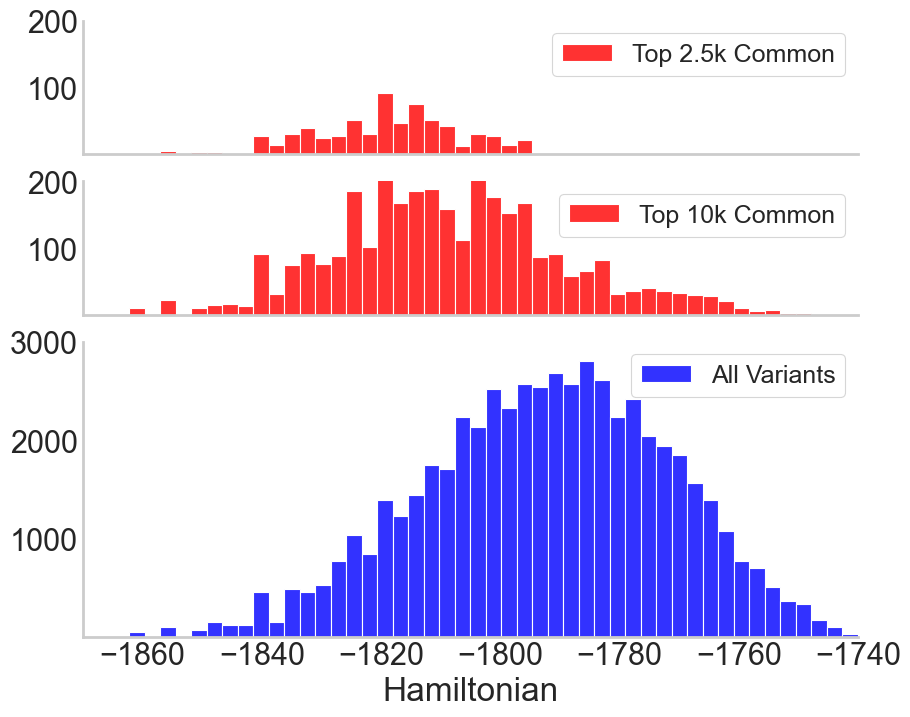

In [18]:
palette = sns.color_palette("bwr", n_colors=9)
bin_edges = np.linspace(-1870, -1740, 51)
sns.set_theme(context='paper', style='whitegrid', font="Arial", font_scale=2.5)  # Adjust font size and style
plt.figure(figsize=(10, 8))
for idxlab,lab in enumerate(['Top 2.5k Common','Top 10k Common']):
    ax = plt.subplot2grid((4, 1), (idxlab, 0))
    sns.histplot(combined_AMP[combined_AMP['Dataset'] == lab]['H_fam'], bins=bin_edges, color=palette[-1], alpha=1, label=lab, stat='count',ax=ax)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2)  # Thicker y-axis
    ax.spines["bottom"].set_linewidth(2)  # Thicker x-axis
    ax.set_ylim(0, 200)  # Set y-axis limits
    ax.set_xlim(-1870, -1740)  # Set x-axis limits
    ax.set_xticklabels([]); ax.set_xlabel('')
    ax.set_ylabel('');
    ax.set_yticks([100,200])
    ax.grid(False)
    # Add tick marks (larks)
    plt.tick_params(axis='both', which='both', direction='in', length=6, width=1.5)  # Customize length and width
    plt.legend(loc='upper right', fontsize=18)

ax = plt.subplot2grid((4, 1), (2, 0),rowspan=2)
sns.histplot(Average_AMP_selected_cleaned['H_fam'], bins=bin_edges, color=palette[0], alpha=1, label='All Variants', stat='count',ax=ax)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(2)  # Thicker y-axis
ax.spines["bottom"].set_linewidth(2)  # Thicker x-axis
ax.grid(False)  # Remove grid
# ax.set_ylim(0, 0.02)  # Set y-axis limits
ax.set_xlim(-1870, -1740)  # Set x-axis limits
ax.set_xlabel('Hamiltonian')
ax.set_ylabel('')
ax.set_yticks([1000,2000,3000])
plt.legend(loc='upper right', fontsize=18)

# Add tick marks (larks)
plt.tick_params(axis='both', which='both', direction='in', length=6, width=1.5)  # Customize length and width
plt.savefig(CleanFigDir / "Ridge_Histogram_H_fam_by_Dataset_6C.png", dpi=600, bbox_inches="tight", transparent=True)
plt.savefig(CleanFigDir / "Ridge_Histogram_H_fam_by_Dataset_6C.pdf", dpi=600, bbox_inches="tight", transparent=True)


## MSA for LGL
We built an MSa for the CML library. We sort them based on the Fitness score at the chosen concentration ([AMP] = 781 µg ml⁻¹ and [AZT] = 36 µg ml⁻¹). Hearders are made from the mutational Profile and the fitness score.

In [19]:
# Function to replace positions in the base string
def replace_positions(base_string, positions, profile):
    base_list = list(base_string)  # Convert string to list for mutability
    for pos, char in zip(positions, profile[2:]):
        if char != '.':
            base_list[pos - 1] = char  # Replace (convert 1-based to 0-based indexing)
    return ''.join(base_list)  # Convert list back to string

# Apply the function to each row of the DataFrame
Average_AMP_selected_cleaned.loc[:,'Seq_wrtPF13354'] = Average_AMP_selected_cleaned['Profile'].apply(lambda profile: replace_positions(str(TEM1_record.seq), mutatedPositions, profile))
Average_AZT_selected_cleaned.loc[:,'Seq_wrtPF13354'] = Average_AZT_selected_cleaned['Profile'].apply(lambda profile: replace_positions(str(TEM1_record.seq), mutatedPositions, profile))

# Create a list of SeqRecord objects
records = []
for _, row in Average_AMP_selected_cleaned.sort_values(by=['781.0']).iterrows():
    record = SeqRecord(Seq(row['Seq_wrtPF13354']), id=str(row['781.0']), description=row['Profile'])
    records.append(record)
AMP_MSA_wrtPF13354_file_Sophia = MSADir / 'AMP_MSA_wrtPF13354_781_headers.fasta'
# Write the SeqRecord objects to a FASTA file
SeqIO.write(records, AMP_MSA_wrtPF13354_file_Sophia, "fasta")

# Create a list of SeqRecord objects
records = []
for _, row in Average_AZT_selected_cleaned.sort_values(by=['36.0']).iterrows():
    record = SeqRecord(Seq(row['Seq_wrtPF13354']), id=str(row['36.0']), description= row['Profile'])
    records.append(record)
AZT_MSA_wrtPF13354_file_Sophia = MSADir / 'AZT_MSA_wrtPF13354_36_headers.fasta'
# Write the SeqRecord objects to a FASTA file
SeqIO.write(records, AZT_MSA_wrtPF13354_file_Sophia, "fasta")

55293

## Supplementary figure 6


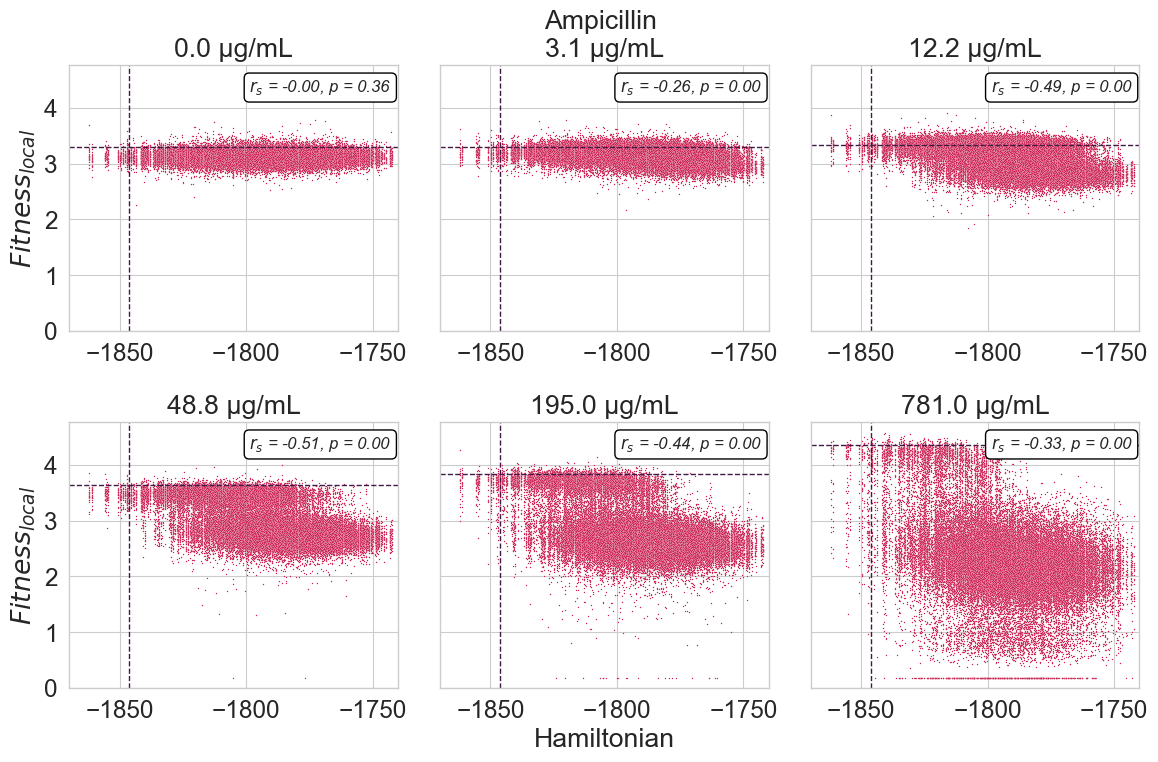

In [20]:
palette = sns.color_palette("rocket", n_colors=5)
sns.set_theme(context='paper',style='whitegrid', font="Arial", font_scale=2)  # Adjust font size and style

max_amp_fit = Average_AMP_selected_cleaned[concentration_amp].max().max()
min_amp_fit = Average_AMP_selected_cleaned[concentration_amp].min().min()

plt.figure(figsize=(12, 8))
for idx_c, conc in enumerate(concentration_amp):
    ax = plt.subplot(2, 3, idx_c+1)
    sns.scatterplot(data=Average_AMP_selected_cleaned, x='H_fam', y=conc, alpha=1,s=1,color=palette[2])
    valid = Average_AMP_selected_cleaned[['H_fam', conc]].dropna()
    r, p = spearmanr(valid['H_fam'], valid[conc])
    ax.text(
        0.98, 0.95, f'$r_s$ = {r:.2f}, p = {p:.2f}',
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=12, fontstyle='italic',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', linewidth=1)
    )
    plt.vlines(x=TEM1_ham_fam, ymin=0, ymax=5, color=palette[0], ls='dashed', lw=1)
    WT_AUC_AMP = Average_AMP_selected_cleaned[Average_AMP_selected_cleaned['N. Mut.'] == 0][conc].values[0]
    plt.hlines(y=WT_AUC_AMP, xmin=-1870, xmax=-1740, color=palette[0], ls='dashed', lw=1)


    if idx_c == 0 or idx_c == 3:
        plt.ylabel(r'$Fitness_{local}$')
    else:
        plt.ylabel('')
        ax.set_yticklabels([])
        
    if idx_c == 1:
        plt.title('Ampicillin \n'+conc+' µg/mL')
    else:
        plt.title(conc+' µg/mL')
    plt.ylim(0,max_amp_fit+0.2)
    plt.xlim(-1870, -1740)

    if idx_c == 4:
        plt.xlabel('Hamiltonian')
    else:
        plt.xlabel('')

plt.tight_layout()
plt.savefig(CleanFigDir / 'AMP_H_fam_vs_Fitness_S6.png', dpi=600, bbox_inches='tight', transparent=True)
plt.savefig(CleanFigDir / 'AMP_H_fam_vs_Fitness_S6.pdf', dpi=600, bbox_inches='tight', transparent=True)

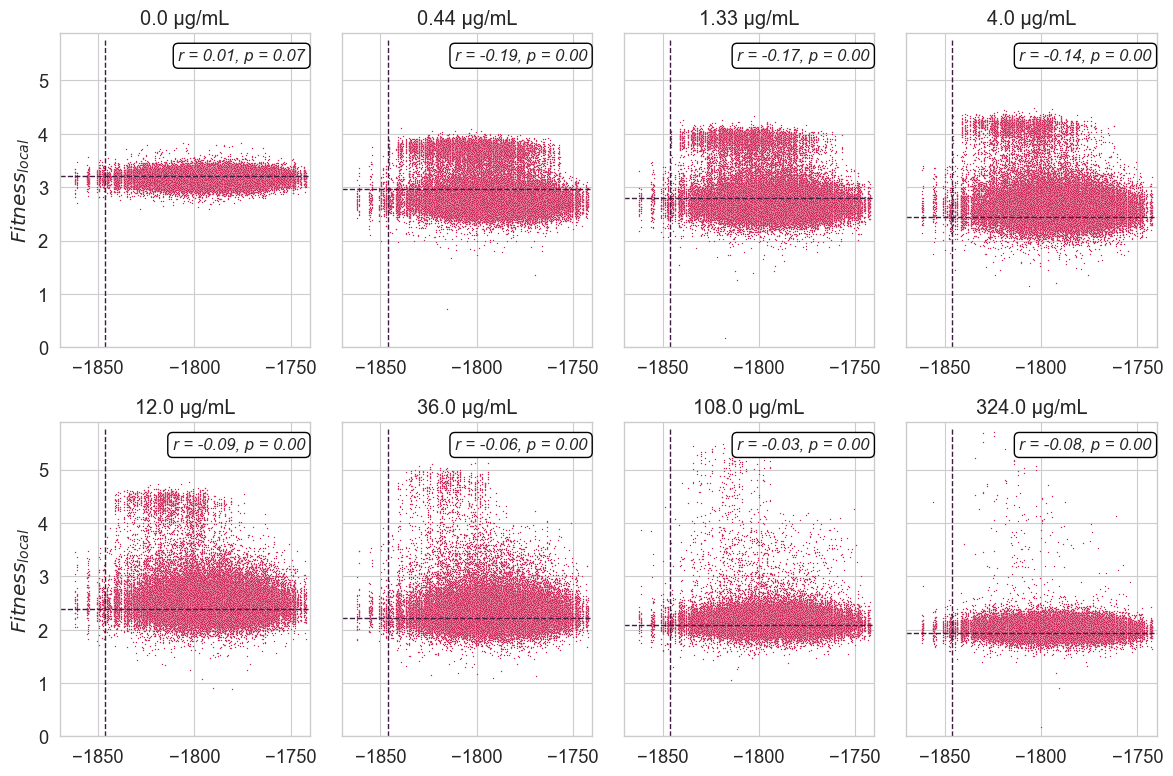

In [21]:
palette = sns.color_palette("rocket", n_colors=5)
sns.set_theme(context='paper',style='whitegrid', font="Arial", font_scale=1.5)  # Adjust font size and style

max_azt_fit = Average_AZT_selected_cleaned[concentration_azt].max().max()
min_azt_fit = Average_AZT_selected_cleaned[concentration_azt].min().min()

plt.figure(figsize=(12, 8))
for idx_c, conc in enumerate(concentration_azt):
    ax = plt.subplot(2, 4, idx_c+1)
    sns.scatterplot(data=Average_AZT_selected_cleaned, x='H_fam', y=conc, alpha=1,s=1,color=palette[2])
    valid = Average_AZT_selected_cleaned[['H_fam', conc]].dropna()
    r, p = spearmanr(valid['H_fam'], valid[conc])
    ax.text(
        0.98, 0.95, f'r = {r:.2f}, p = {p:.2f}',
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=12, fontstyle='italic',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', linewidth=1)
    )
    plt.vlines(x=TEM1_ham_fam, ymin=0, ymax=max_azt_fit+0.1, color=palette[0], ls='dashed', lw=1)
    WT_AUC_AZT = Average_AZT_selected_cleaned[Average_AZT_selected_cleaned['N. Mut.'] == 0][conc].values[0]
    plt.hlines(y=WT_AUC_AZT, xmin=-1870, xmax=-1740, color=palette[0], ls='dashed', lw=1)

    if idx_c == 0 or idx_c == 4:
        plt.ylabel(r'$Fitness_{local}$')
    else:
        plt.ylabel('')
        ax.set_yticklabels([])
        
    plt.title(conc+' µg/mL')
    plt.ylim(0,max_azt_fit+0.2)
    plt.xlim(-1870, -1740)

    plt.xlabel('')

plt.tight_layout()
plt.savefig(CleanFigDir / 'AZT_H_fam_vs_Fitness.png', dpi=600, bbox_inches='tight', transparent=True)
plt.savefig(CleanFigDir / 'AZT_H_fam_vs_Fitness.pdf', dpi=600, bbox_inches='tight', transparent=True)